In [1]:


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/Moon Mapping/DataSet')


In [ ]:
import os
%cd ~
%cd /content/drive/MyDrive/Moon Mapping/DataSet/
%ls
print(os.listdir())


/root
/content/drive/.shortcut-targets-by-id/19TyNbSyd7i1igZMVw4YRX5xonl55yZTb/Moon Mapping/DataSet
 ch2_ohrc_data_products_user_guide.pdf   GT/                          Test/
 ch2_tmc2_data_products_user_guide.pdf   Misc/                        test.ipynb
 dataset_prep2.ipynb                     Moon_Mapping.ipynb           test.py
 dataset_prep3.ipynb                     OHRC/                        TMC/
 dataset_prep.ipynb                      __pycache__/                 tmc_break.py
'file1 (3).csv'                          readOHRC.py                  tmc_ohrc_intersections.ipynb
 Gen2.py                                 result.png
 Generator.py                           'Supplementary Files-OHRC'/
['dataset_prep3.ipynb', 'ch2_ohrc_data_products_user_guide.pdf', 'ch2_tmc2_data_products_user_guide.pdf', 'tmc_ohrc_intersections.ipynb', 'test.ipynb', 'OHRC', 'Supplementary Files-OHRC', 'Misc', 'readOHRC.py', 'dataset_prep.ipynb', 'TMC', 'test.py', 'Test', 'GT', 'result.png', 'Generato

In [3]:
!pip install spherical_geometry
!pip install geographiclib
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon
import cv2
import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from matplotlib.patches import Polygon as MatplotlibPolygon
import geopandas as gpd
from geographiclib.geodesic import Geodesic
# from tmc_break import get_pix_coor, transform_img
from spherical_geometry import graph, great_circle_arc, polygon, vector

%load_ext autoreload
%autoreload 2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 50.1 MB/s eta 0:00:00


In [4]:
def file_coords(xml_file_path = r'E:\ISRO PS-Transformer\DataSet\OHRC\ch2_ohr_nrp_20200229T0938004033_d_img_d32\data\raw\20200229\ch2_ohr_nrp_20200229T0938004033_d_img_d32.xml'):
    tree = ET.parse(xml_file_path)
    root = tree.getroot()

    # Define the namespace dictionary
    namespace = {
        'isda': 'https://isda.issdc.gov.in/pds4/isda/v1',
    }

    # Function to extract latitude and longitude values
    def extract_coordinates(element):
        coordinates = element.find('.//isda:System_Level_Coordinates', namespace)
        upper_left_latitude = coordinates.find('./isda:upper_left_latitude', namespace).text
        upper_left_longitude = coordinates.find('./isda:upper_left_longitude', namespace).text

        upper_right_latitude = coordinates.find('./isda:upper_right_latitude', namespace).text
        upper_right_longitude = coordinates.find('./isda:upper_right_longitude', namespace).text

        lower_left_latitude = coordinates.find('./isda:lower_left_latitude', namespace).text
        lower_left_longitude = coordinates.find('./isda:lower_left_longitude', namespace).text

        lower_right_latitude = coordinates.find('./isda:lower_right_latitude', namespace).text
        lower_right_longitude = coordinates.find('./isda:lower_right_longitude', namespace).text

        return [(lower_left_longitude, lower_left_latitude), (lower_right_longitude, lower_right_latitude), (upper_right_longitude, upper_right_latitude), (upper_left_longitude, upper_left_latitude)]

    # Extract coordinates from the XML
    coordinates = extract_coordinates(root)
    # Print the results
    return coordinates

def SphericalPoly(img_corners):
  coordinates_xyz = [vector.normalize_vector(vector.lonlat_to_vector(float(lon), float(lat), degrees=True)) for lon, lat in img_corners]
  inside_point = great_circle_arc.midpoint(coordinates_xyz[0], coordinates_xyz[2])
  poly = polygon.SingleSphericalPolygon(coordinates_xyz, inside=inside_point)
  return poly

def cut_out_quadrilateral(image_path, output_path, src_coordinates, dst_coordinates):
    # Read the image
    image = cv2.imread(image_path)

    # Convert the coordinates to NumPy arrays
    src_pts = np.array(src_coordinates, dtype=np.float32)
    dst_pts = np.array(dst_coordinates, dtype=np.float32)

    # Calculate the perspective transformation matrix
    perspective_matrix = cv2.getPerspectiveTransform(src_pts, dst_pts)

    # Apply the perspective transformation to obtain the cut-out region
    warped_image = cv2.warpPerspective(image, perspective_matrix, (image.shape[1], image.shape[0]))

    # Save the cut-out region to a new image file
    cv2.imwrite(output_path, warped_image)

files1={}
files2={}

def iterate_files(base_dir):
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.xml'):
                file_path = os.path.join(root, file)
                return file_path

def iterate_images(base_dir):
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.png'):
                file_path = os.path.join(root, file)
                return file_path

def browse_folders(base_dir, data):
    for entry in os.scandir(base_dir):
        if entry.is_dir():
            folder_name = entry.name
            data[folder_name] = file_coords(iterate_files(os.path.join(base_dir, folder_name, "data")))



# Function to find XML files and generate PNG file link
def parse_xml_and_get_png(xml_file_path, base_dir):
    # Extracting information from XML file path
    xml_filename = os.path.basename(xml_file_path)
    date_folder = os.path.basename(os.path.dirname(xml_file_path))
    channel = xml_filename.split('_')[0]

    # Creating corresponding PNG file path
    png_filename = xml_filename.replace('d_img', 'b_brw').replace('.xml', '.png')
    png_file_path = os.path.join(base_dir, 'browse', 'calibrated', date_folder, png_filename)

    return png_file_path

# Function to parse all XML files under the 'data\calibrated' directory and create a dictionary
def parse_all_xml_files(directory, base_dir):
    xml_files_dict = {}
    for root, dirs, files in os.walk(os.path.join(base_dir, 'data', 'calibrated')):
        for file in files:
            if file.endswith('.xml'):
                xml_file_path = os.path.join(root, file)
                png_file_path = parse_xml_and_get_png(xml_file_path, base_dir)
                xml_files_dict[file] = [file_coords(xml_file_path), png_file_path]

    return xml_files_dict

def find_common_area(poly1_coords, poly2_coords):
    # Create GeoDataFrame with the provided coordinates and custom CRS for the Moon
    moon_crs = "+proj=longlat +a=1737400 +b=1737400 +no_defs"  # Example CRS for the Moon
    poly1 = Polygon(poly1_coords)
    poly2 = Polygon(poly2_coords)

    gdf = gpd.GeoDataFrame(geometry=[poly1, poly2], crs=moon_crs)
    gdf.plot()
    # Find the intersection of the two polygons
    intersection = gdf.geometry.iloc[0].intersection(gdf.geometry.iloc[1])

    # Check if there is a common area
    if intersection.geom_type == 'MultiPolygon':
        common_area_coords = []
        for polygon in intersection:
            common_area_coords.extend(list(polygon.exterior.coords))
    else:
        common_area_coords = list(intersection.exterior.coords)


    return common_area_coords


base_dir = r'/content/drive/MyDrive/Moon Mapping/DataSet/OHRC/files'
xml_files_dict_ohrc = parse_all_xml_files(os.path.join(base_dir, 'data', 'calibrated'), base_dir)


coor_csv = pd.read_csv(r"/content/drive/MyDrive/Moon Mapping/DataSet/TMC/coordinates.csv")
def iterate_tmc(base_dir, coor_csv):
    tmc_files = {}
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.png'):
                file_path = os.path.join(root, file)
                filename =file.split('_b')[0]
                row = coor_csv[coor_csv['Filename'].str.startswith(filename)]
                upper_left_latitude = row['upper_left_latitude'].iloc[0]
                upper_left_longitude = row['upper_left_longitude'].iloc[0]

                upper_right_latitude = row['upper_right_latitude'].iloc[0]
                upper_right_longitude = row['upper_right_longitude'].iloc[0]

                lower_left_latitude = row['lower_left_latitude'].iloc[0]
                lower_left_longitude = row['lower_left_longitude'].iloc[0]

                lower_right_latitude = row['lower_right_latitude'].iloc[0]
                lower_right_longitude = row['lower_right_longitude'].iloc[0]

                tmc_files[file] = [[(lower_left_longitude, lower_left_latitude), (lower_right_longitude, lower_right_latitude), (upper_right_longitude, upper_right_latitude), (upper_left_longitude, upper_left_latitude)], file_path]

    return tmc_files

def polar_angle_with_respect_to_first(point, reference_point):
    x, y = point[0] - reference_point[0], point[1] - reference_point[1]
    return math.atan2(y, x) if(x!=0 or y!=0) else -10

def polar_sort(points):
    reference_point = points[0]
    return sorted(points, key=lambda point: polar_angle_with_respect_to_first(point, reference_point))

def transform_img(image, vertices):
    # Create a black mask with the same size as the image
    mask = np.zeros_like(image)
    vertices = np.array(polar_sort(vertices))
    # Fill the polygon in the mask
    cv2.fillPoly(mask, [vertices], color=(255, 255, 255))
    # Bitwise AND operation to get the cropped region
    result = cv2.bitwise_and(image, mask)

    return result

def crop_img(image, vertices):
    # Define the source and destination corner coordinates
    print(vertices) #Debug Statement
    src_corners = np.float32([[0, 0], [0, image.shape[0]], [image.shape[1], 0], [image.shape[1], image.shape[0]]])
    # [[ullong, ullat], [lllong,lllat], [urlong, urlat], [lrlong, lrlat]]
    dst_corners = np.float32(vertices)

    # Calculate the perspective transformation matrix
    matrix = cv2.getPerspectiveTransform(src_corners, dst_corners)
    print(vertices) #Debug Statement
    # Apply the transformation
    size = int(max(max(vertices)) - min(min(vertices)))
    print((size))
    result = cv2.warpPerspective(image, matrix, (size, size))

    return result

In [5]:
def get_pix_coor(carr, query, shape):
    # Define the Moon's ellipsoid parameters
    moon_ellipsoid = Geodesic.WGS84
    moon_ellipsoid.a = 1738.1  # Semi-major axis
    moon_ellipsoid.f = 0.0     # Flattening (since it's a sphere)

    ref_line = moon_ellipsoid.InverseLine(carr['ult'],carr['ulg'],carr['llt'],carr['llg'])

    conv_fact = max(shape)/ref_line.s13
    print("conversion Factor: ", conv_fact)

    target_line = moon_ellipsoid.InverseLine(carr['ult'],carr['ulg'], query[0], query[1])

    angle = target_line.azi1 - ref_line.azi1

    target_refl = moon_ellipsoid.Direct(carr['ult'], carr['ulg'], (target_line.azi1-(2*angle)), target_line.s13)

    perp_line = moon_ellipsoid.InverseLine(target_refl['lat2'], target_refl['lon2'], query[0], query[1])

    perp_base = perp_line.Position(perp_line.s13/2)

    ref_int = moon_ellipsoid.InverseLine(carr['ult'], carr['ulg'], perp_base['lat2'], perp_base['lon2'])

    x = conv_fact*ref_int.s13
    y = conv_fact*perp_line.s13/2

    return [y,x]

In [6]:
xml_files_dict_tmc = iterate_tmc(r'G:\My Drive\Moon Mapping\DataSet\TMC', coor_csv)

output_path1 = r'G:\My Drive\Moon Mapping\DataSet\Test'
output_path2 = r'G:\My Drive\Moon Mapping\DataSet\GT'

In [7]:
iterator = 0
it = 0
for image_tmc in xml_files_dict_tmc:
    for image_ohrc in xml_files_dict_ohrc:
        if(not (np.isnan(xml_files_dict_tmc[image_tmc][0])).any()):
            intersect = find_common_area(xml_files_dict_tmc[image_tmc][0], xml_files_dict_ohrc[image_ohrc][0])
            it += 1
            if(intersect is not None and len(intersect)==5):
                print(intersect)
                intersect.pop()
                # cut_out_quadrilateral(xml_files_dict_tmc[image_tmc][1], output_path1 + rf'\{iterator}_{image_tmc[:-4]}.png', xml_files_dict_tmc[image_tmc][0], intersect)
                # cut_out_quadrilateral(xml_files_dict_ohrc[image_ohrc][1], output_path2 + rf'\{iterator}_{image_ohrc[:-4]}.png', xml_files_dict_ohrc[image_ohrc][0], intersect)
                iterator += 1
                print(iterator)
        else:
            continue

In [8]:
intersection = pd.read_csv("/content/drive/MyDrive/Moon Mapping/DataSet/file1 (3).csv")

In [10]:
import shutil
shutil.rmtree('/content/drive/MyDrive/Moon Mapping/DataSet/GT')

In [11]:
os.mkdir('/content/drive/MyDrive/Moon Mapping/DataSet/GT')

In [26]:
# Run algo for given number of images
for it in range(7,10):
    input_string = intersection['Tmc_Corners'].iloc[it]
    tmc_coords_lon = eval(input_string[1:-1].split('array')[1][:-2])
    tmc_coords_lat = eval(input_string[1:-1].split('array')[2])

    tmc_coords={} # store the tmc corners
    keys = ['llt','llg','ult','ulg','urt','urg','lrt','lrg']


    for i in range(len(tmc_coords_lat)-1):
        tmc_coords[keys[2*i]] = tmc_coords_lat[i]
        tmc_coords[keys[2*i+1]] = tmc_coords_lon[i]

    input_string = intersection['Ohrc_Corners'].iloc[it]
    ohrc_coords_lon = eval(input_string[1:-1].split('array')[1][:-2])
    ohrc_coords_lat = eval(input_string[1:-1].split('array')[2])

    ohrc_coords={} # store the ohrc corners
    for i in range(len(ohrc_coords_lat)-1):
        ohrc_coords[keys[2*i]] = ohrc_coords_lat[i]
        ohrc_coords[keys[2*i+1]] = ohrc_coords_lon[i]

    input_string = intersection['Intersecting_Corners'].iloc[it]
    inter_coords_lon = eval(input_string[1:-1].split('array')[1][:-2])
    inter_coords_lat = eval(input_string[1:-1].split('array')[2])

    inter_coords=[] # store the intersection coordinates
    for i in range(len(inter_coords_lat)-1):
        inter_coords.append([inter_coords_lat[i], inter_coords_lon[i]])

    tmc_image_file = intersection['Tmc_File_Location'].iloc[it]
    ohrc_image_file = intersection['Ohrc_File_Location'].iloc[it]

    print(tmc_image_file)
    print(ohrc_image_file)

    tmc_img = cv2.imread(tmc_image_file)
    pix_inter_coor = []
    print(tmc_coords)
    print(inter_coords)
    # plotevery(tmc_coords, inter_coords, ohrc_coords)
    print("Shape of the tmc", tmc_img.shape)
    for geo_coor in inter_coords:
        pix_coor = get_pix_coor(tmc_coords, geo_coor, tmc_img.shape)
        pix_inter_coor.append(pix_coor)


    vertices = np.array(pix_inter_coor, dtype=np.int32)
    print(vertices[0].dtype)
    print(vertices)
    cropped_tmc = transform_img(tmc_img, vertices)
    plotevery(tmc_coords, inter_coords, ohrc_coords)
    ohrc_img = cv2.imread(ohrc_image_file)
    pix_ohr_coor = []
    for geo_coor in inter_coords:
        pix_coor = get_pix_coor(ohrc_coords, geo_coor, ohrc_img.shape)
        pix_ohr_coor.append(pix_coor)

    vertices = np.array(pix_ohr_coor, dtype=np.int32)
    cropped_ohr = transform_img(ohrc_img, vertices)


    cv2.imwrite(f'/content/drive/MyDrive/Moon Mapping/DataSet/Test/{it}.png', cropped_tmc)
    cv2.imwrite(f'/content/drive/MyDrive/Moon Mapping/DataSet/GT/{it}.png', cropped_ohr)


/content/drive/MyDrive/Moon Mapping/DataSet/TMC/browse_calibrated_2020/dir_2020/20200131/ch2_tmc_ncn_20200131T1010006367_b_brw_d18.png
/content/drive/MyDrive/Moon Mapping/DataSet/OHRC/files/browse/calibrated/20190906/ch2_ohr_ncp_20190906T1246532096_b_brw_d18.png
{'llt': -1.781802, 'llg': 69.953406, 'ult': -32.054427, 'ulg': 69.453333, 'urt': -32.04291, 'urg': 68.781885, 'lrt': -1.772419, 'lrg': 69.396345}
[[-16.72985, 69.174869], [-16.11120305, 69.73681983], [-16.67985332, 69.72775751], [-17.15629, 69.299801]]
Shape of the tmc (18041, 400, 3)
conversion Factor:  0.005383325936892445
conversion Factor:  0.005383325936892445
conversion Factor:  0.005383325936892445
conversion Factor:  0.005383325936892445
int32
[[ 315 9133]
 [   0 9507]
 [   0 9169]
 [ 239 8881]]


AttributeError: 'NoneType' object has no attribute 'xmin'

<Figure size 1000x1000 with 1 Axes>

conversion Factor:  0.017939042398240772
conversion Factor:  0.017939042398240772
conversion Factor:  0.017939042398240772
conversion Factor:  0.017939042398240772
/content/drive/MyDrive/Moon Mapping/DataSet/TMC/browse_calibrated_2020/dir_2020/20200131/ch2_tmc_ncf_20200131T1010006367_b_brw_d18.png
/content/drive/MyDrive/Moon Mapping/DataSet/OHRC/files/browse/calibrated/20190906/ch2_ohr_ncp_20190906T1246532096_b_brw_d18.png
{'llt': -0.480831, 'llg': 70.003706, 'ult': -30.722178, 'ulg': 69.513933, 'urt': -30.708822, 'urg': 68.78025, 'lrt': -0.469688, 'lrg': 69.386657}
[[-16.72985, 69.174869], [-16.07468402, 69.76983931], [-16.64289209, 69.76083474], [-17.15629, 69.299801]]
Shape of the tmc (18041, 400, 3)
conversion Factor:  0.005389550759610567
conversion Factor:  0.005389550759610567
conversion Factor:  0.005389550759610567
conversion Factor:  0.005389550759610567
int32
[[ 334 8347]
 [   0 8744]
 [   0 8405]
 [ 258 8094]]


AttributeError: 'NoneType' object has no attribute 'xmin'

<Figure size 1000x1000 with 1 Axes>

conversion Factor:  0.017939042398240772
conversion Factor:  0.017939042398240772
conversion Factor:  0.017939042398240772
conversion Factor:  0.017939042398240772
/content/drive/MyDrive/Moon Mapping/DataSet/TMC/browse_calibrated_2020/dir_2020/20200131/ch2_tmc_nca_20200131T1010006367_b_brw_d18.png
/content/drive/MyDrive/Moon Mapping/DataSet/OHRC/files/browse/calibrated/20190906/ch2_ohr_ncp_20190906T1246532096_b_brw_d18.png
{'llt': -3.088126, 'llg': 69.96361, 'ult': -33.389256, 'ulg': 69.463782, 'urt': -33.376474, 'urg': 68.706832, 'lrt': -3.077869, 'lrg': 69.344413}
[[-16.64239205, 69.76128212], [-17.15629, 69.299801], [-16.72985, 69.174869], [-16.0743106, 69.77017686]]
Shape of the tmc (18041, 400, 3)
conversion Factor:  0.005377587363775826
conversion Factor:  0.005377587363775826
conversion Factor:  0.005377587363775826
conversion Factor:  0.005377587363775826
int32
[[    0  9977]
 [  258  9667]
 [  334  9920]
 [    0 10315]]


AttributeError: 'NoneType' object has no attribute 'xmin'

<Figure size 1000x1000 with 1 Axes>

conversion Factor:  0.017939042398240772
conversion Factor:  0.017939042398240772
conversion Factor:  0.017939042398240772
conversion Factor:  0.017939042398240772


In [ ]:
image = cv2.imread('/content/drive/MyDrive/Moon Mapping/DataSet/TMC/browse_calibrated_2019/dir_2019/20191125/ch2_tmc_nca_20191125T0749024661_b_brw_d18.png')
# Define the vertices of the polygon (clockwise or counterclockwise order)
vertices = np.array([[10, 10], [300, 0], [350, 250], [0, 280]], dtype=np.int32)

result1 = transform_img(image, vertices)

plt.figure(figsize=(8,8))
plt.imshow(result1)


In [90]:
!pip install -q basemap
!pip install gdal
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
import cv2
import scipy.ndimage

40.82416880573712


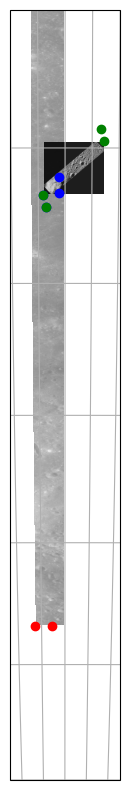

In [106]:
plotevery(tmc_coords, inter_coords, ohrc_coords)

In [105]:
def plotevery(t, i, o):
    tmc_lats = [t['llt'], t['ult'], t['urt'], t['lrt']]
    tmc_lons = [t['llg'], t['ulg'], t['urg'], t['lrg']]
    ohr_lats = [o['llt'], o['ult'], o['urt'], o['lrt']]
    ohr_lons = [o['llg'], o['ulg'], o['urg'], o['lrg']]
    int_lons = [j[1] for j in i]
    int_lats = [j[0] for j in i]

    # Create a Cartopy GeoAxes instance and define the map projection
    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Orthographic(central_longitude=tmc_lons[0], central_latitude=tmc_lats[0])}, figsize=(10,10))

    # Plot the data using scatter
    ax.scatter(tmc_lons, tmc_lats, marker='o', color='red', transform=ccrs.PlateCarree(), zorder=5)
    ax.scatter(int_lons, int_lats, color='b', transform=ccrs.PlateCarree(), zorder=5)
    ax.scatter(ohr_lons, ohr_lats, color='g', transform=ccrs.PlateCarree(), zorder=5)

    # Add coastlines and country borders as features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Set the bounding box for the zoomed-in area
    bbox = [68, 72, -40, -10]
    ax.set_extent(bbox, crs=ccrs.PlateCarree())

    image = plt.imread(tmc_image_file)
    # Define the extent of the image in PlateCarree coordinates
    image_extent = [tmc_lons[0] , tmc_lons[2], tmc_lats[0], tmc_lats[2]]
    # Plot the image overlay
    ax.imshow(image, origin='upper', extent=image_extent, transform=ccrs.PlateCarree(), alpha=0.5, cmap='gray')

    image = plt.imread(ohrc_image_file)
    # Define the extent of the image in PlateCarree coordinates
    image_extent = [ohr_lons[0] , ohr_lons[2], ohr_lats[0], ohr_lats[2]]
    # Define the Moon's ellipsoid parameters
    moon_ellipsoid = Geodesic.WGS84
    moon_ellipsoid.a = 1738.1  # Semi-major axis
    moon_ellipsoid.f = 0.0
    ref_line = moon_ellipsoid.InverseLine(ohr_lats[1],ohr_lons[1],ohr_lats[0],ohr_lons[0])
    print(ref_line.azi1)
    rotated_image = scipy.ndimage.rotate(image, ref_line.azi1+90, reshape=True)
    # Plot the image overlay
    ax.imshow(rotated_image, origin='upper', extent=image_extent, transform=ccrs.PlateCarree(), alpha=0.9, cmap='gray')

    # Draw meridians
    ax.gridlines()

    plt.show()

In [69]:
def plotevery(t, i, o):
    tmc_lats=[t['llt'], t['ult'], t['urt'], t['lrt']]
    tmc_lons=[t['llg'], t['ulg'], t['urg'], t['lrg']]
    ohr_lats=[o['llt'], o['ult'], o['urt'], o['lrt']]
    ohr_lons=[o['llg'], o['ulg'], o['urg'], o['lrg']]
    int_lons=[j[1] for j in i]
    int_lats=[j[0] for j in i]

    # Create a Basemap instance and define the map projection
    fig = plt.figure(figsize=(10,10))
    # m = Basemap(projection='ortho', lat_0=tmc_lats[0], lon_0=tmc_lons[0], llcrnrlat=tmc_lats[0], urcrnrlat=tmc_lats[2], llcrnrlon=tmc_lons[0]-5, urcrnrlon=tmc_lons[2]+5)
    m = Basemap(projection='ortho', lat_0=tmc_lats[0],lon_0=tmc_lons[0])

    # Convert the latitude and longitude points to the x,y coordinates on the map
    x, y = m(tmc_lons, tmc_lats)
    cx,cy = m(int_lons, int_lats)
    ox, oy = m(ohr_lons, ohr_lats)

    # Plot the data using scatter
    m.scatter(x, y, marker='o', color='red', zorder=5)
    m.scatter(cx,cy,color='b',zorder=5)
    m.scatter(ox,oy,color='g',zorder=5)
    # m.imshow(p4,origin='upper', extent=(7269240, 8500296,2866405,5872929))
    xmin, ymin = m([60], [-40])
    xmax, ymax = m([70], [0])
    print(xmin, ymin, xmax, ymax, sep=" ")
    ax = plt.gca()
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([ymin, ymax])
    m.drawmeridians(range(-180,180,20))
    plt.show()

In [73]:
!pip install -q cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 23.8 MB/s eta 0:00:00
